K-Means

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from scipy.cluster.hierarchy import dendrogram, linkage
from kneed import KneeLocator
import hdbscan
import warnings

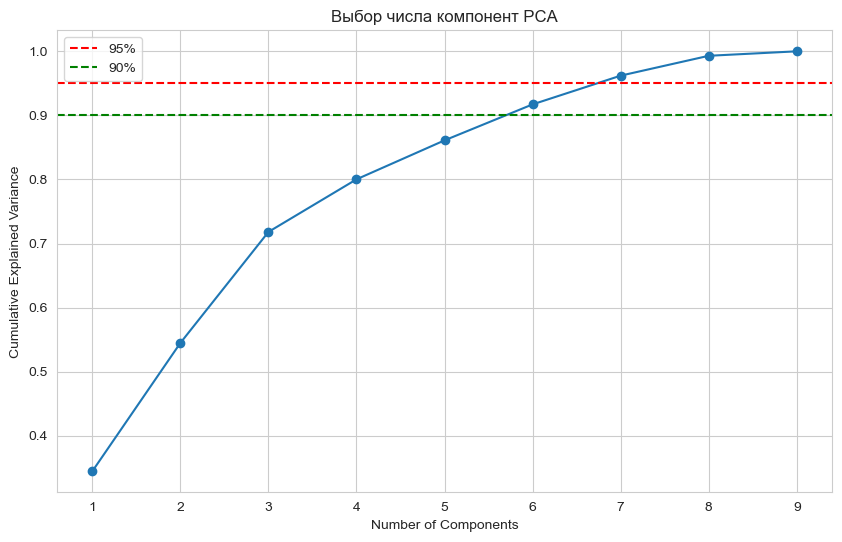

Для 95% дисперсии нужно 7 компонент
Для 90% дисперсии нужно 6 компонент


In [37]:
warnings.filterwarnings('ignore')

data = pd.read_csv('archive/Wholesale customers data.csv')

categorical_cols = ['Channel', 'Region']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

numeric_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

expl_var = pca.explained_variance_ratio_
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components = len(cum_var)
components = np.arange(1, n_components + 1)

plt.figure(figsize=(10,6))
plt.plot(components, cum_var, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.axhline(y=0.90, color='g', linestyle='--', label='90%')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Выбор числа компонент PCA')
plt.legend()
plt.grid(True)
plt.show()

n_95 = np.argmax(cum_var >= 0.95) + 1
n_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Для 95% дисперсии нужно {n_95} компонент")
print(f"Для 90% дисперсии нужно {n_90} компонент")

In [38]:
n_pca = 6
pca_kmeans = PCA(n_components=n_pca, random_state=42)
X_pca_kmeans = pca_kmeans.fit_transform(X_scaled)

sample_size = min(5000, X_pca_kmeans.shape[0])
np.random.seed(42)
sample_idx = np.random.choice(X_pca_kmeans.shape[0], size=sample_size, replace=False)
X_sample_kmeans = X_pca_kmeans[sample_idx]

K_range = range(2, 10)
silhouette_scores = []
best_k = None
best_score = -1

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_pca_kmeans)
    labels_sample = kmeans.predict(X_sample_kmeans)
    score = silhouette_score(X_sample_kmeans, labels_sample)
    silhouette_scores.append(score)
    print(f"K = {k:2d} | Silhouette = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"\nОптимальное K = {best_k} (силуэт = {best_score:.4f})")

K =  2 | Silhouette = 0.3575
K =  3 | Silhouette = 0.3356
K =  4 | Silhouette = 0.3839
K =  5 | Silhouette = 0.3886
K =  6 | Silhouette = 0.3910
K =  7 | Silhouette = 0.3980
K =  8 | Silhouette = 0.3825
K =  9 | Silhouette = 0.3954

Оптимальное K = 7 (силуэт = 0.3980)


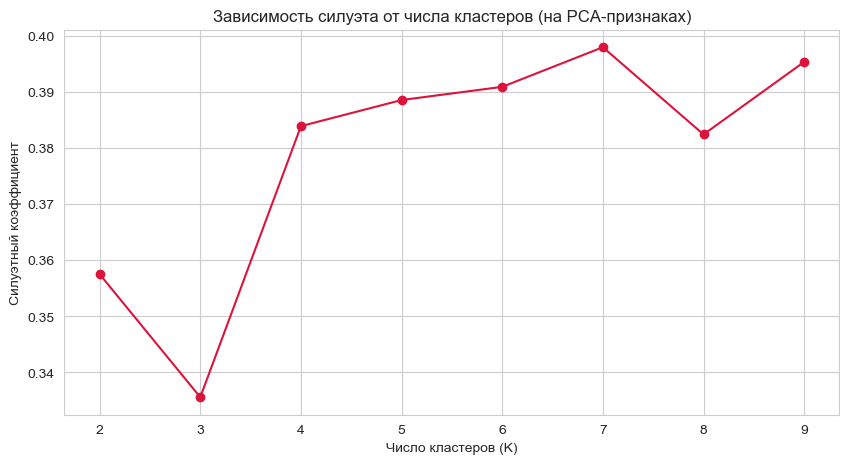

In [39]:
plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, marker='o', color='crimson')
plt.xlabel('Число кластеров (K)')
plt.ylabel('Силуэтный коэффициент')
plt.title('Зависимость силуэта от числа кластеров (на PCA-признаках)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

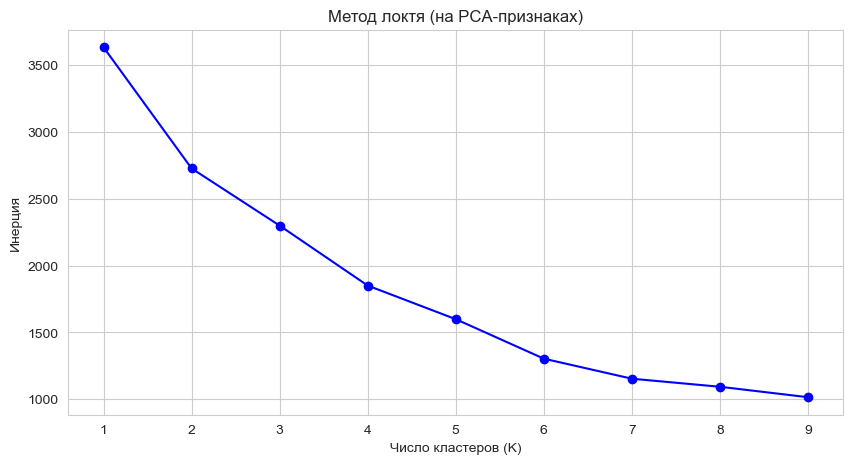

In [40]:
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_pca_kmeans)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 10), inertia, marker='o', color='blue')
plt.xlabel('Число кластеров (K)')
plt.ylabel('Инерция')
plt.title('Метод локтя (на PCA-признаках)')
plt.grid(True)
plt.show()

In [41]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
cluster_labels_kmeans = final_kmeans.fit_predict(X_pca_kmeans)
data['cluster_kmeans'] = cluster_labels_kmeans

print("\nРаспределение объектов по кластерам (K-Means):")
print(data['cluster_kmeans'].value_counts().sort_index())


Распределение объектов по кластерам (K-Means):
cluster_kmeans
0    111
1    225
2     10
3     45
4     46
5      2
6      1
Name: count, dtype: int64


In [42]:
cluster_profile_mean_kmeans = data.groupby('cluster_kmeans')[numeric_cols].mean()
cluster_profile_median_kmeans = data.groupby('cluster_kmeans')[numeric_cols].median()

print("\nСредние значения признаков по кластерам (K-Means):")
print(cluster_profile_mean_kmeans.round(2))

print("\nМедианные значения признаков по кластерам (K-Means):")
print(cluster_profile_median_kmeans.round(2))


Средние значения признаков по кластерам (K-Means):
                   Fresh      Milk   Grocery    Frozen  Detergents_Paper  \
cluster_kmeans                                                             
0                8029.23   9103.56  14263.63   1466.59           5921.21   
1                8733.60   3042.60   3445.47   2662.76            835.39   
2               15964.90  34708.50  48536.90   3054.60          24875.20   
3                9409.76   4830.67   7830.00   2869.60           2976.38   
4               38257.85   4934.50   5793.30   6470.61            834.11   
5               22015.50   9937.00   7844.00  47939.00            671.50   
6               36847.00  43950.00  20170.00  36534.00            239.00   

                Delicassen  
cluster_kmeans              
0                  1759.86  
1                   979.81  
2                  2942.80  
3                  1059.60  
4                  2647.43  
5                  4153.50  
6                 47943.00  

М

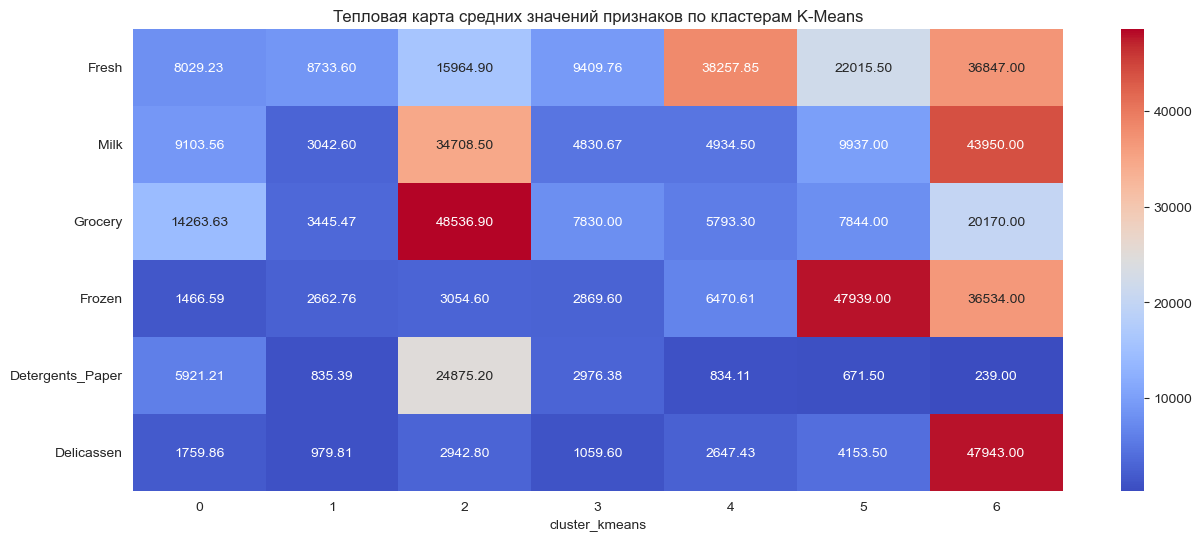

In [43]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

plt.figure(figsize=(15, 6))
sns.heatmap(cluster_profile_mean_kmeans.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта средних значений признаков по кластерам K-Means')
plt.show()

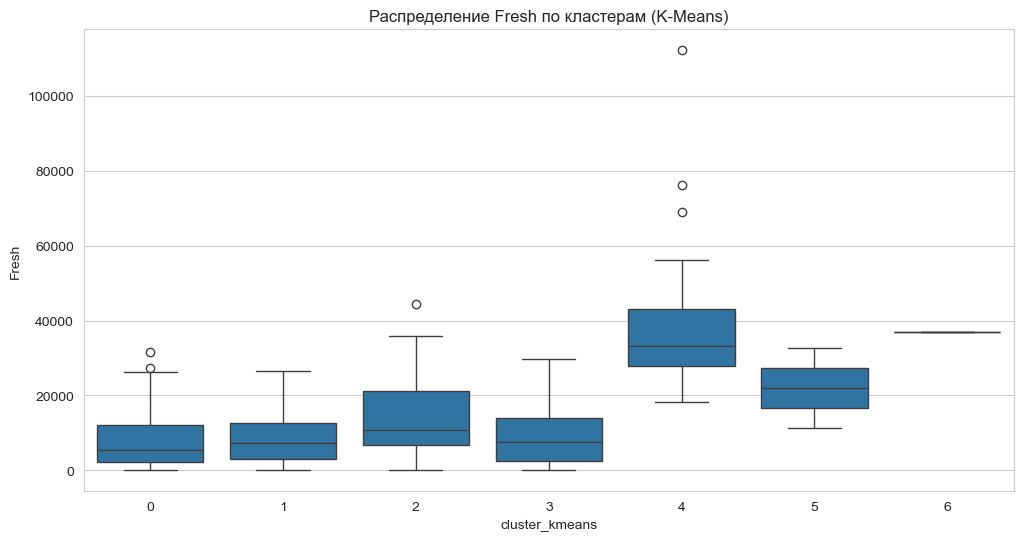

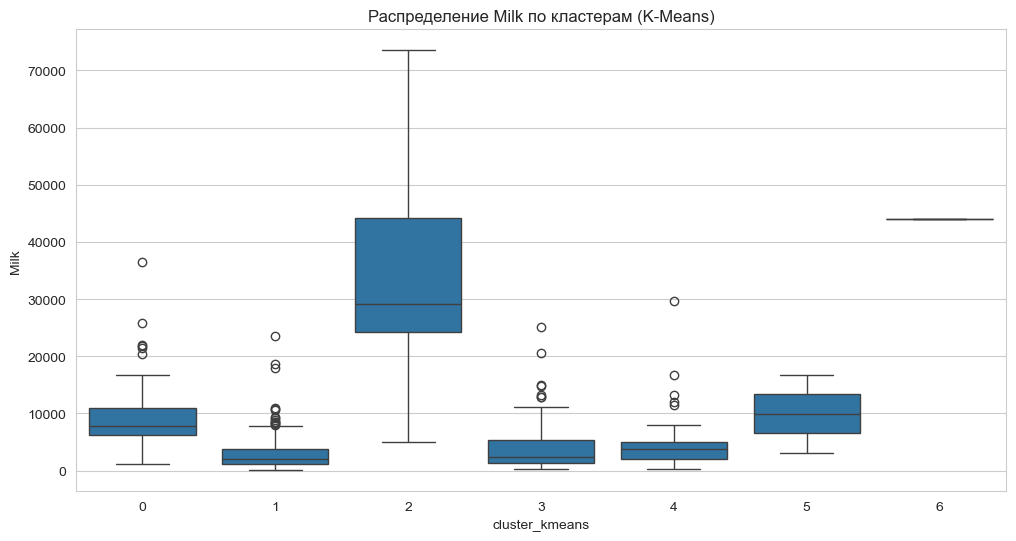

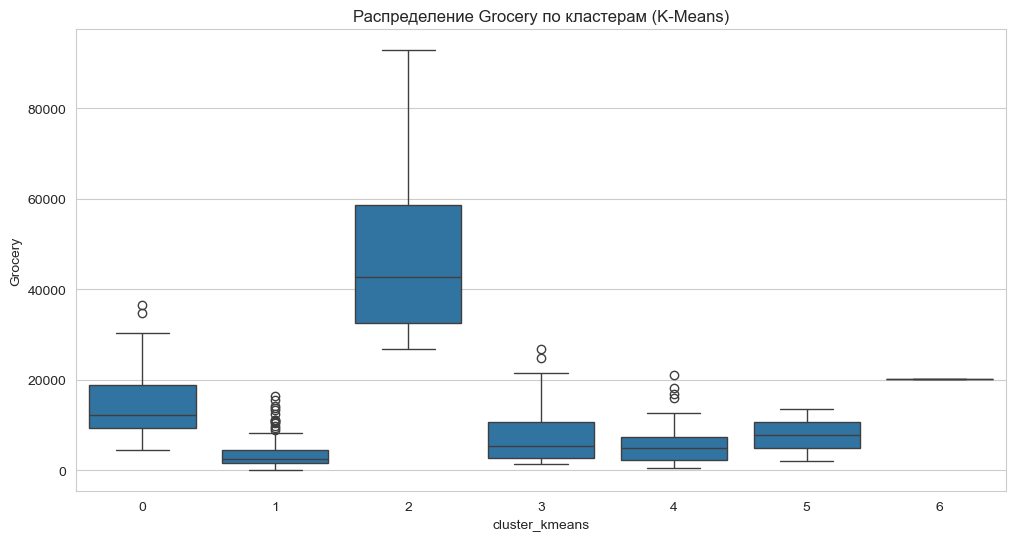

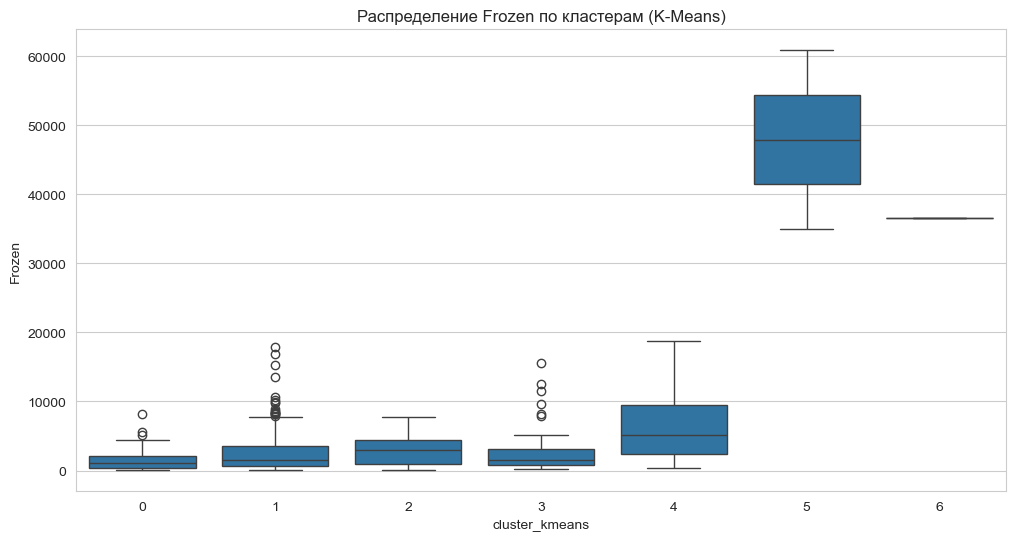

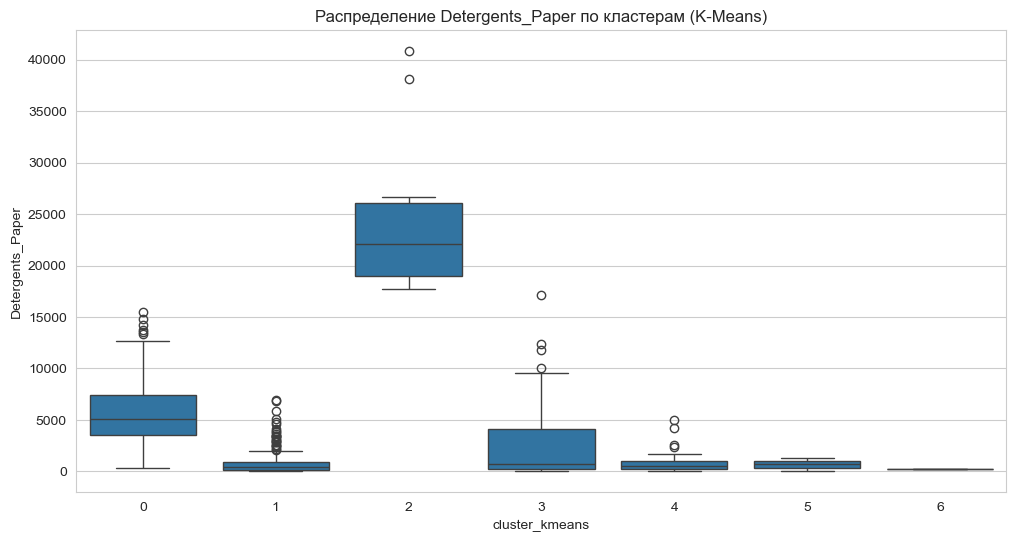

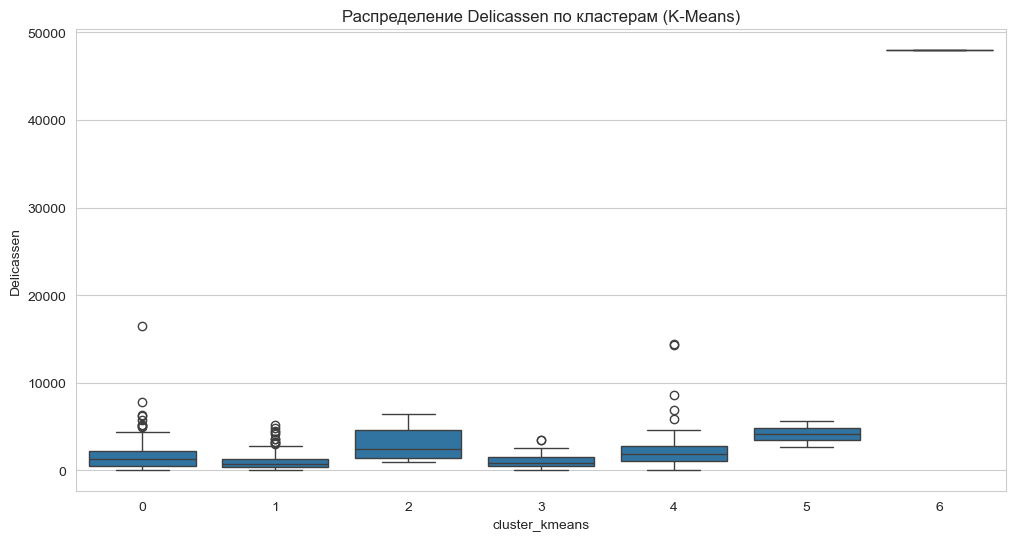

In [44]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(data=data, x='cluster_kmeans', y=col)
    plt.title(f'Распределение {col} по кластерам (K-Means)')
    plt.show()

In [45]:
cat_cols = [col for col in data.columns if col not in numeric_cols + ['cluster_kmeans']]
cluster_cat_profile_kmeans = data.groupby('cluster_kmeans')[cat_cols].mean()
print("\nСредние значения one-hot признаков по кластерам (K-Means):")
print(cluster_cat_profile_kmeans.round(2))


Средние значения one-hot признаков по кластерам (K-Means):
                Channel_2  Region_2  Region_3
cluster_kmeans                               
0                    0.99       0.0      0.87
1                    0.01       0.0      0.76
2                    1.00       0.1      0.70
3                    0.40       1.0      0.00
4                    0.04       0.0      0.83
5                    0.00       0.5      0.50
6                    0.00       0.0      1.00


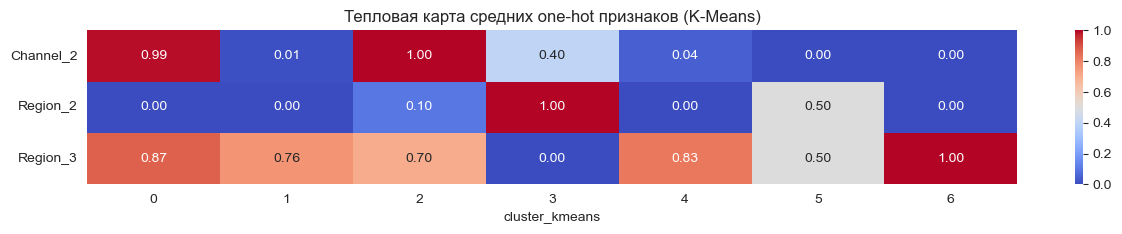

In [59]:
plt.figure(figsize=(15, 2))
sns.heatmap(cluster_cat_profile_kmeans.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта средних one-hot признаков (K-Means)')
plt.show()

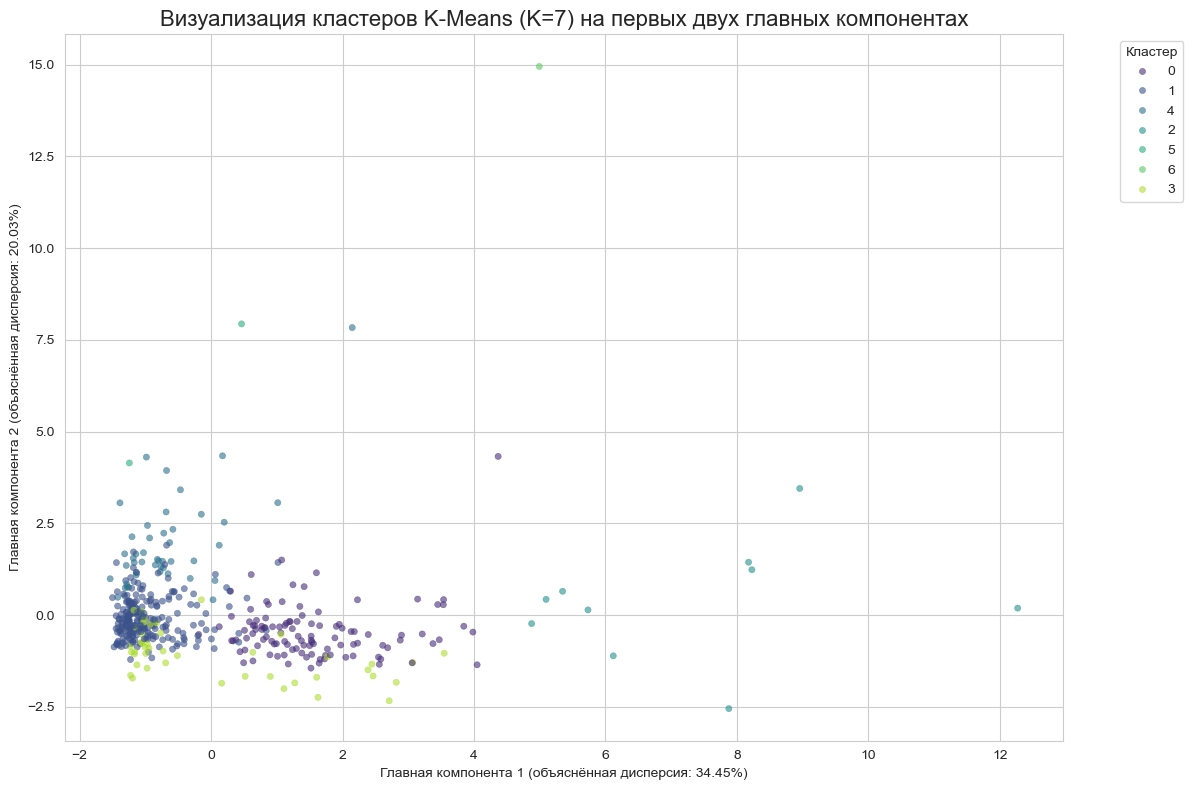

In [47]:
pca_df_kmeans = pd.DataFrame({
    'PCA1': X_pca_kmeans[:, 0],
    'PCA2': X_pca_kmeans[:, 1],
    'Cluster': cluster_labels_kmeans.astype(str)
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=pca_df_kmeans,
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette='viridis',
    alpha=0.6,
    edgecolor=None,
    s=20
)
plt.title(f'Визуализация кластеров K-Means (K={best_k}) на первых двух главных компонентах', fontsize=16)
plt.xlabel(f'Главная компонента 1 (объяснённая дисперсия: {pca_kmeans.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Главная компонента 2 (объяснённая дисперсия: {pca_kmeans.explained_variance_ratio_[1]:.2%})')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

DBSCAN

Автоматически найденный eps = 2.52


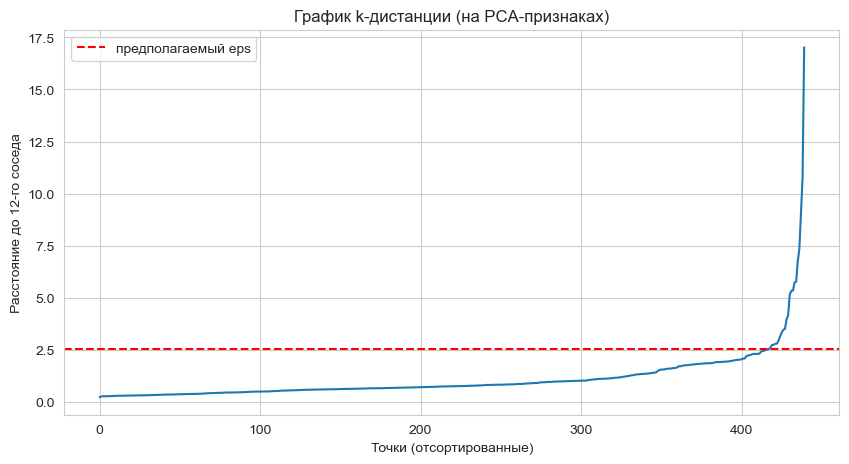

In [68]:
n_components_dbscan = 6
pca_dbscan = PCA(n_components=n_components_dbscan, random_state=42)
X_pca_dbscan = pca_dbscan.fit_transform(X_scaled)

min_samples = 12
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_pca_dbscan)
distances, _ = nn.kneighbors(X_pca_dbscan)
k_distances = distances[:, -1]
k_distances_sorted = np.sort(k_distances)

kneedle = KneeLocator(
    range(len(k_distances_sorted)),
    k_distances_sorted,
    curve='convex',
    direction='increasing'
)
eps_auto = k_distances_sorted[kneedle.knee]
print(f"Автоматически найденный eps = {eps_auto:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(k_distances_sorted)
plt.axhline(y=eps_auto, color='r', linestyle='--', label='предполагаемый eps')
plt.xlabel('Точки (отсортированные)')
plt.ylabel(f'Расстояние до {min_samples}-го соседа')
plt.title('График k-дистанции (на PCA-признаках)')
plt.legend()
plt.grid(True)
plt.show()

In [69]:
min_cluster_size = 12
clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                            metric='euclidean',
                            cluster_selection_method='eom')
labels_hdbscan = clusterer.fit_predict(X_pca_dbscan)

n_clusters_hdbscan = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
n_noise_hdbscan = list(labels_hdbscan).count(-1)
print(f"\nИтог (HDBSCAN): кластеров = {n_clusters_hdbscan}, шумовых точек = {n_noise_hdbscan} "
      f"({100*n_noise_hdbscan/len(labels_hdbscan):.1f}%)")


Итог (HDBSCAN): кластеров = 4, шумовых точек = 67 (15.2%)


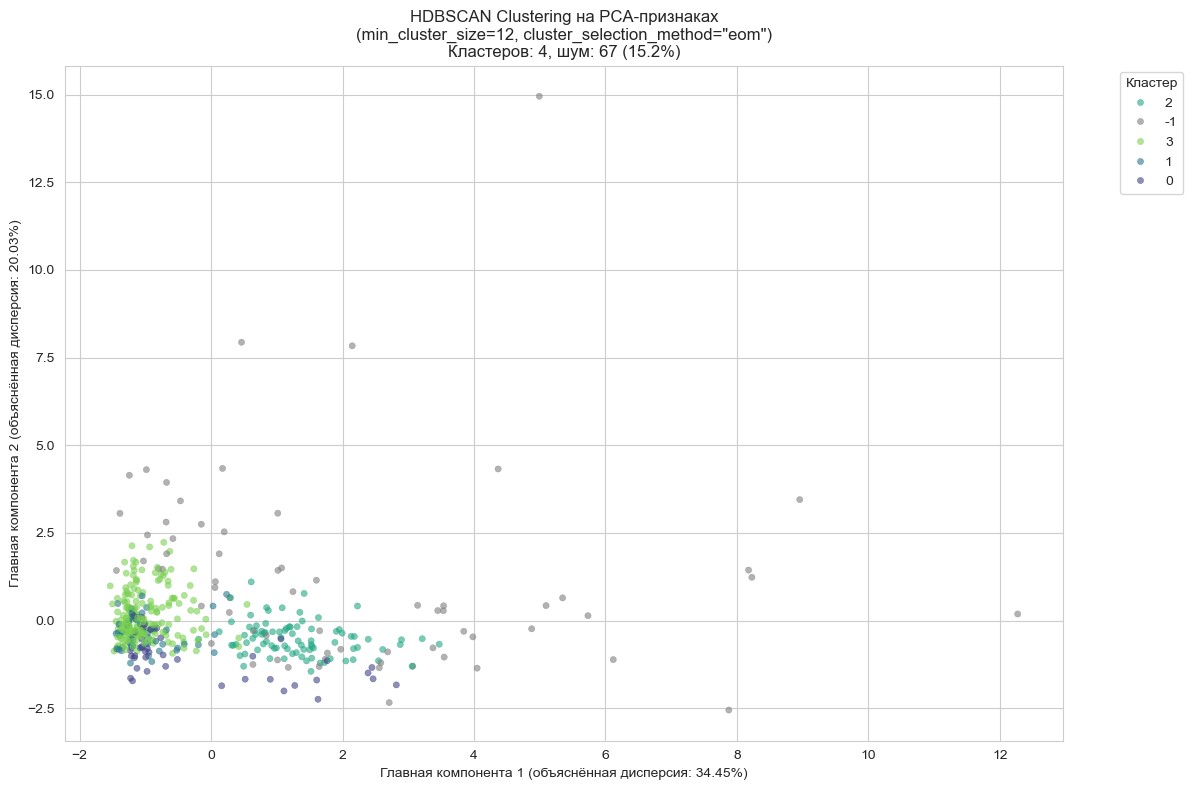

In [70]:
pca_df_hdbscan = pd.DataFrame({
    'PCA1': X_pca_dbscan[:, 0],
    'PCA2': X_pca_dbscan[:, 1],
    'Cluster': labels_hdbscan.astype(str)
})

palette_hdbscan = {str(i): color for i, color in enumerate(sns.color_palette("viridis", n_clusters_hdbscan))}
palette_hdbscan['-1'] = (0.5, 0.5, 0.5)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=pca_df_hdbscan,
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette=palette_hdbscan,
    alpha=0.6,
    edgecolor=None,
    s=20
)
plt.title(f'HDBSCAN Clustering на PCA-признаках\n'
          f'(min_cluster_size={min_cluster_size}, cluster_selection_method="eom")\n'
          f'Кластеров: {n_clusters_hdbscan}, шум: {n_noise_hdbscan} ({100*n_noise_hdbscan/len(labels_hdbscan):.1f}%)')
plt.xlabel(f'Главная компонента 1 (объяснённая дисперсия: {pca_dbscan.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Главная компонента 2 (объяснённая дисперсия: {pca_dbscan.explained_variance_ratio_[1]:.2%})')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Средние значения признаков по кластерам (HDBSCAN, без шума):
                    Fresh     Milk   Grocery   Frozen  Detergents_Paper  \
cluster_hdbscan                                                           
0                 9587.35  4310.75   6973.25  2458.40           2361.40   
1                10153.22  3131.18   3404.67  2413.88            892.31   
2                 8191.64  7882.98  12813.48  1399.51           5409.01   
3                11993.57  2879.86   3438.23  2749.29            757.14   

                 Delicassen  
cluster_hdbscan              
0                   1019.42  
1                    900.43  
2                   1310.01  
3                   1038.88  

Медианные значения признаков по кластерам (HDBSCAN, без шума):
                  Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
cluster_hdbscan                                                               
0                7357.5  2272.0   5200.5  1460.0             708.0       851.0
1     

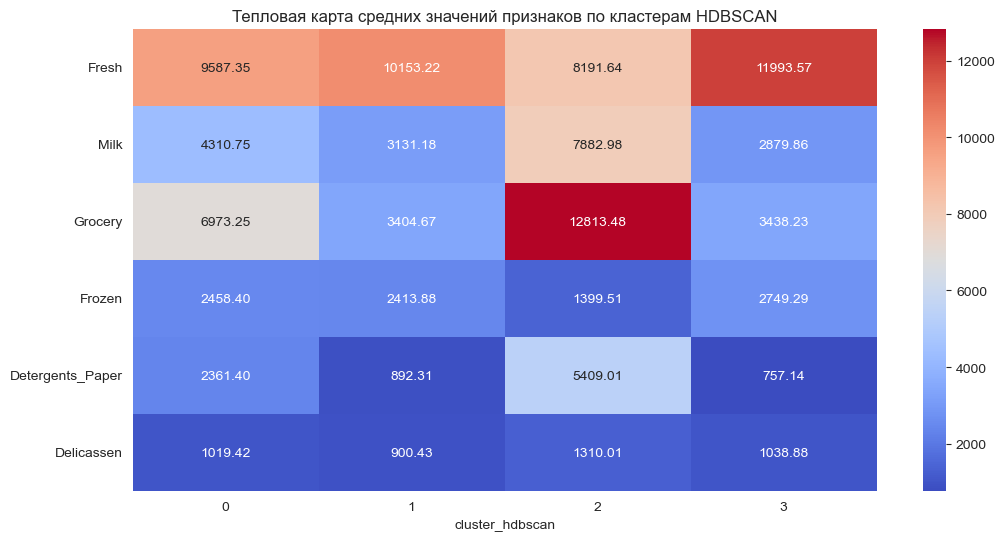

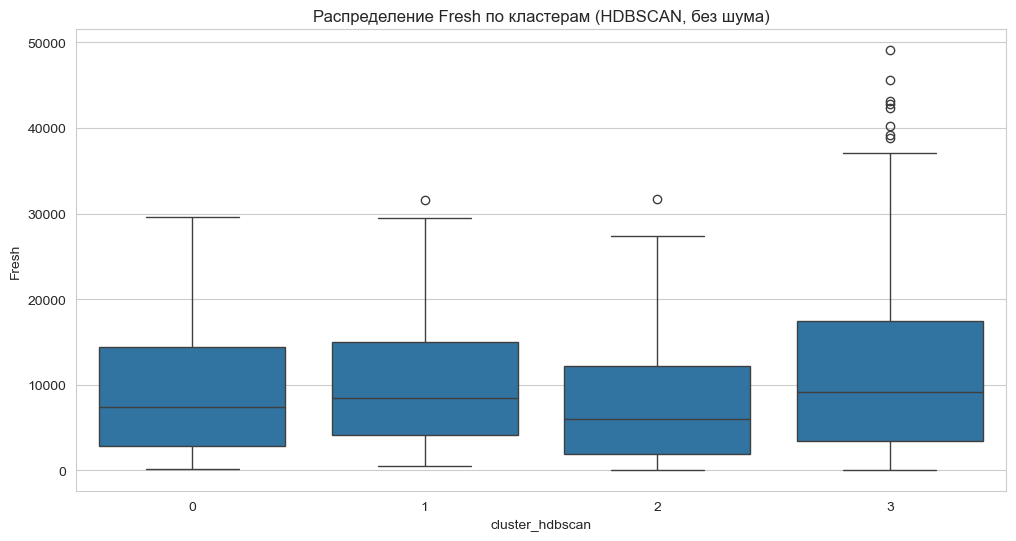

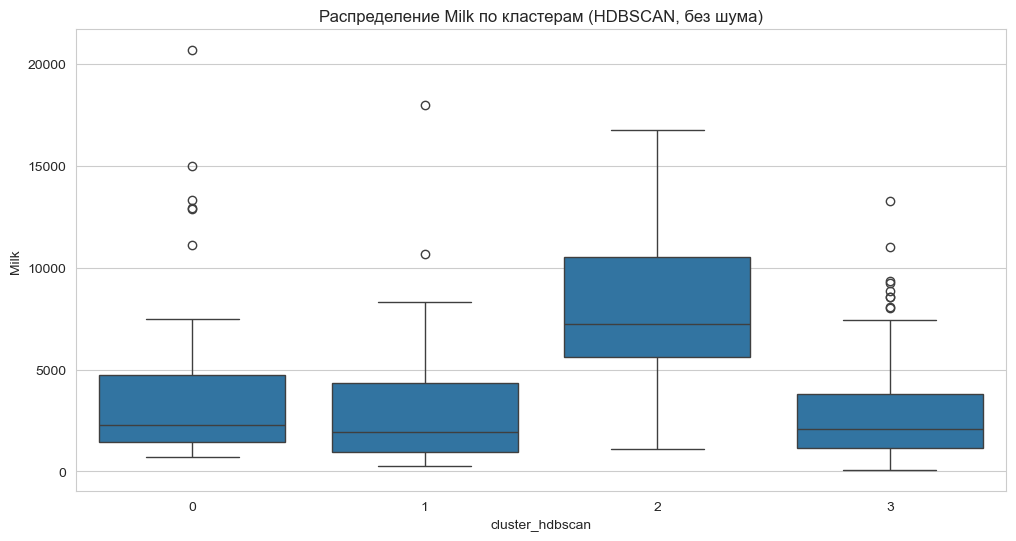

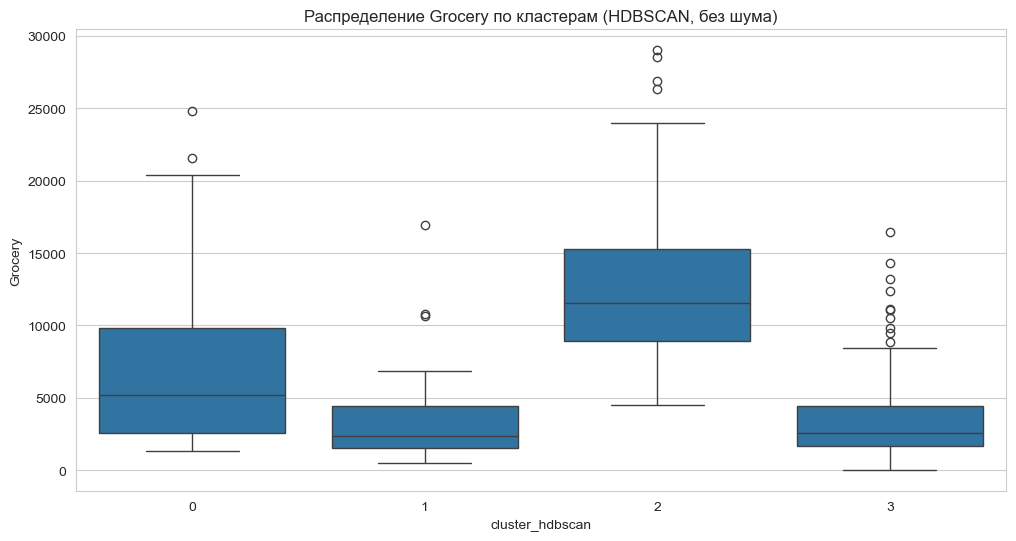

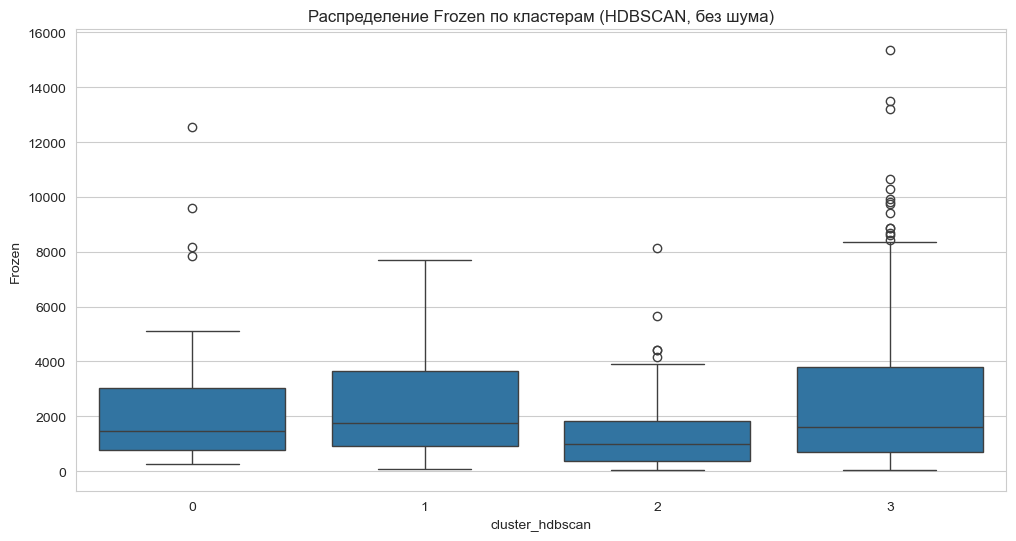

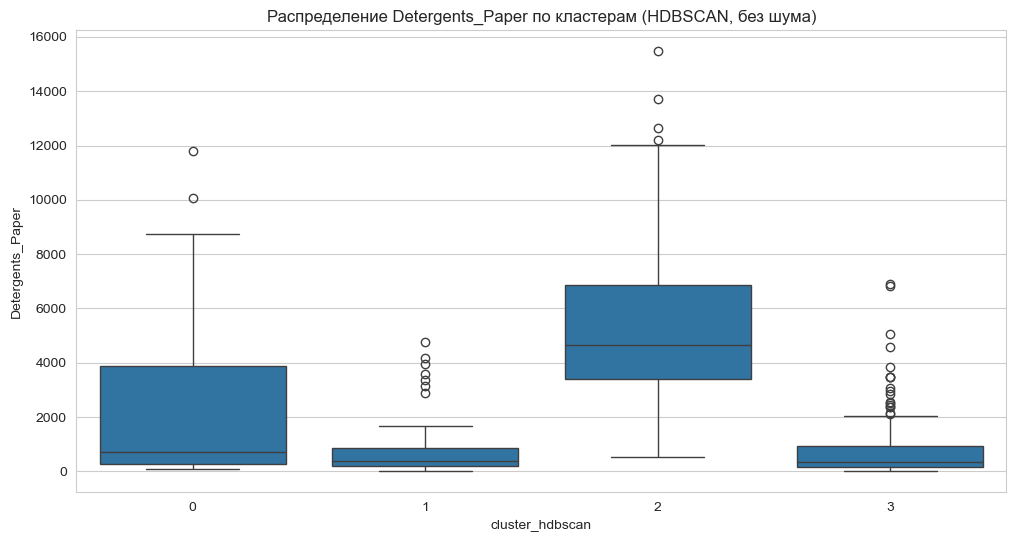

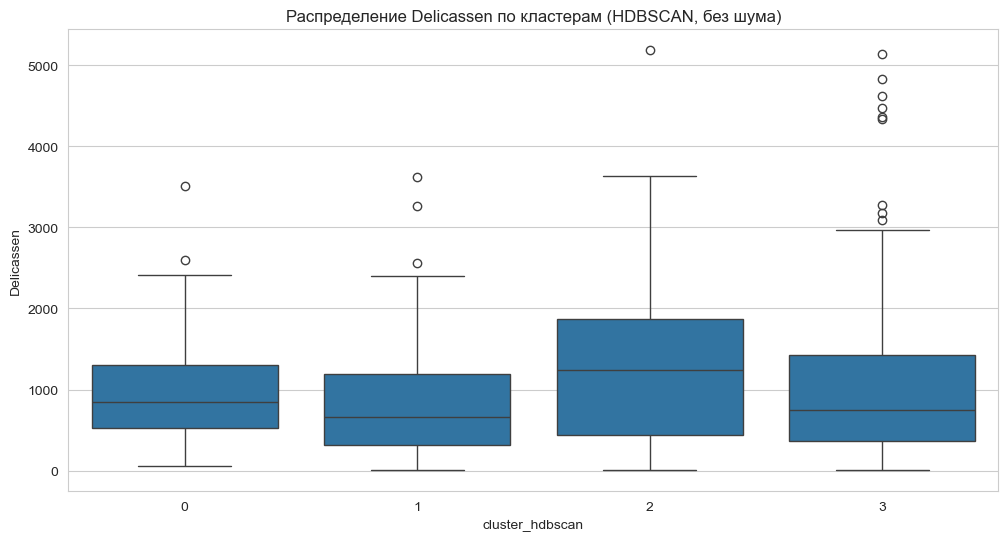


Средние значения one-hot признаков по кластерам (HDBSCAN, без шума):
                 Channel_2  Region_2  Region_3  cluster_kmeans  cluster_agg
cluster_hdbscan                                                            
0                     0.35       1.0       0.0            3.00         0.00
1                     0.00       0.0       0.0            1.12         0.02
2                     1.00       0.0       1.0            0.00         0.99
3                     0.00       0.0       1.0            1.40         0.01


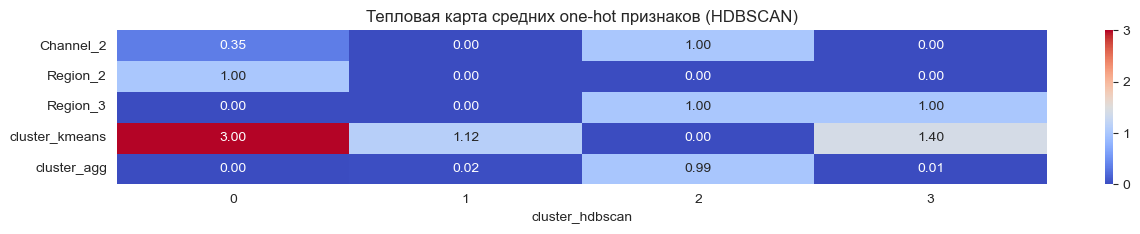

In [76]:
data['cluster_hdbscan'] = labels_hdbscan

df_no_noise_hdbscan = data[data['cluster_hdbscan'] != -1].copy()

if len(df_no_noise_hdbscan) > 0:
    cluster_profile_mean_hdbscan = df_no_noise_hdbscan.groupby('cluster_hdbscan')[numeric_cols].mean()
    cluster_profile_median_hdbscan = df_no_noise_hdbscan.groupby('cluster_hdbscan')[numeric_cols].median()

    print("\nСредние значения признаков по кластерам (HDBSCAN, без шума):")
    print(cluster_profile_mean_hdbscan.round(2))

    print("\nМедианные значения признаков по кластерам (HDBSCAN, без шума):")
    print(cluster_profile_median_hdbscan.round(2))

    plt.figure(figsize=(12, 6))
    sns.heatmap(cluster_profile_mean_hdbscan.T, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Тепловая карта средних значений признаков по кластерам HDBSCAN')
    plt.show()

    for col in numeric_cols:
        plt.figure()
        sns.boxplot(data=df_no_noise_hdbscan, x='cluster_hdbscan', y=col)
        plt.title(f'Распределение {col} по кластерам (HDBSCAN, без шума)')
        plt.show()

    cat_cols_hdbscan = [col for col in data.columns if col not in numeric_cols + ['cluster_hdbscan']]
    cluster_cat_profile_hdbscan = df_no_noise_hdbscan.groupby('cluster_hdbscan')[cat_cols_hdbscan].mean()
    print("\nСредние значения one-hot признаков по кластерам (HDBSCAN, без шума):")
    print(cluster_cat_profile_hdbscan.round(2))

    plt.figure(figsize=(15, 2))
    sns.heatmap(cluster_cat_profile_hdbscan.T, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Тепловая карта средних one-hot признаков (HDBSCAN)')
    plt.show()

AgglomerativeClustering

Оптимальное число кластеров (по наибольшему разрыву): 3


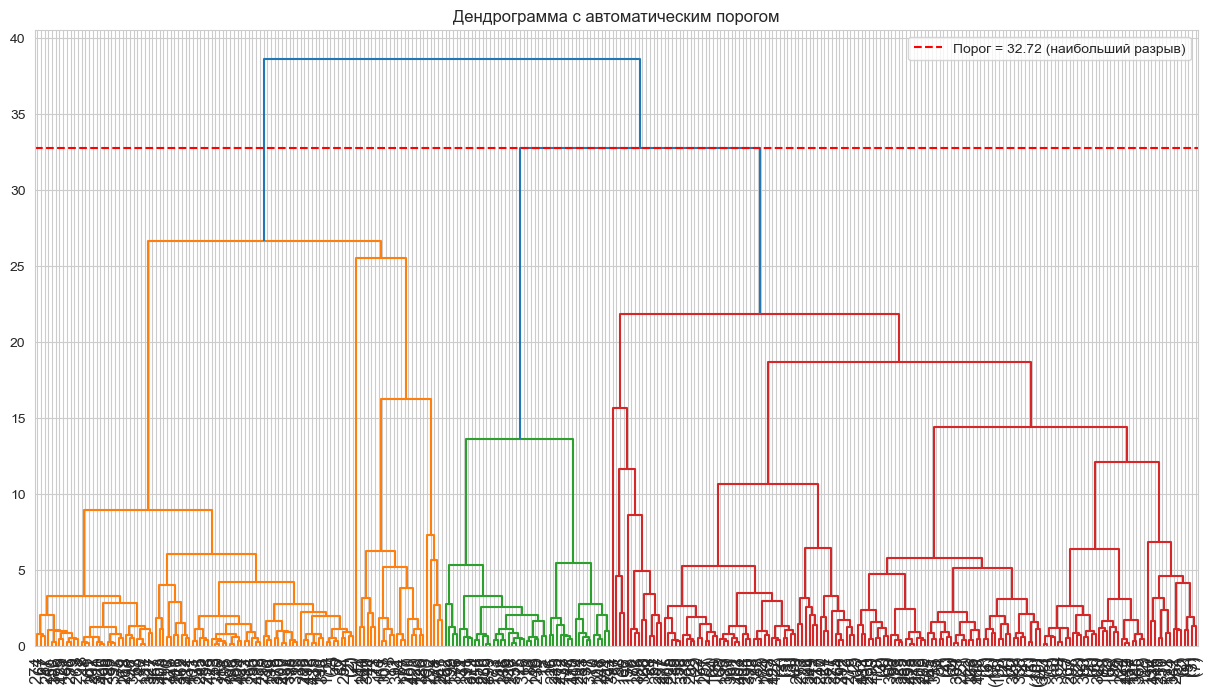

In [81]:
n_pca_agg = 6
pca_agg = PCA(n_components=n_pca_agg, random_state=42)
X_pca_agg = pca_agg.fit_transform(X_scaled)

sample_size_agg = min(25000, X_pca_agg.shape[0])
indices_agg = np.random.choice(X_pca_agg.shape[0], sample_size_agg, replace=False)
X_sample_agg = X_pca_agg[indices_agg]

linkage_matrix = linkage(X_sample_agg, method='ward', metric='euclidean')
distances_agg = linkage_matrix[:, 2]
diffs_agg = np.diff(distances_agg)
max_diff_idx_agg = np.argmax(diffs_agg) + 1
optimal_n_clusters_agg = sample_size_agg - max_diff_idx_agg

print(f"Оптимальное число кластеров (по наибольшему разрыву): {optimal_n_clusters_agg}")

plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, truncate_mode='level', p=10,
           leaf_rotation=90., leaf_font_size=12.)
plt.axhline(y=distances_agg[max_diff_idx_agg], color='r', linestyle='--',
            label=f'Порог = {distances_agg[max_diff_idx_agg]:.2f} (наибольший разрыв)')
plt.legend()
plt.title('Дендрограмма с автоматическим порогом')
plt.show()

In [82]:
n_clusters_agg = optimal_n_clusters_agg

clusterer_agg = AgglomerativeClustering(n_clusters=n_clusters_agg, linkage='ward')
labels_sample_agg = clusterer_agg.fit_predict(X_sample_agg)

knn_agg = KNeighborsClassifier(n_neighbors=1)
knn_agg.fit(X_sample_agg, labels_sample_agg)
labels_agg = knn_agg.predict(X_pca_agg)

unique_labels_agg = set(labels_agg)
n_clusters_found_agg = len(unique_labels_agg)
n_noise_agg = 0
print(f"\nИтог (AgglomerativeClustering + KNN): кластеров = {n_clusters_found_agg}, "
      f"шумовых точек = {n_noise_agg}")


Итог (AgglomerativeClustering + KNN): кластеров = 3, шумовых точек = 0


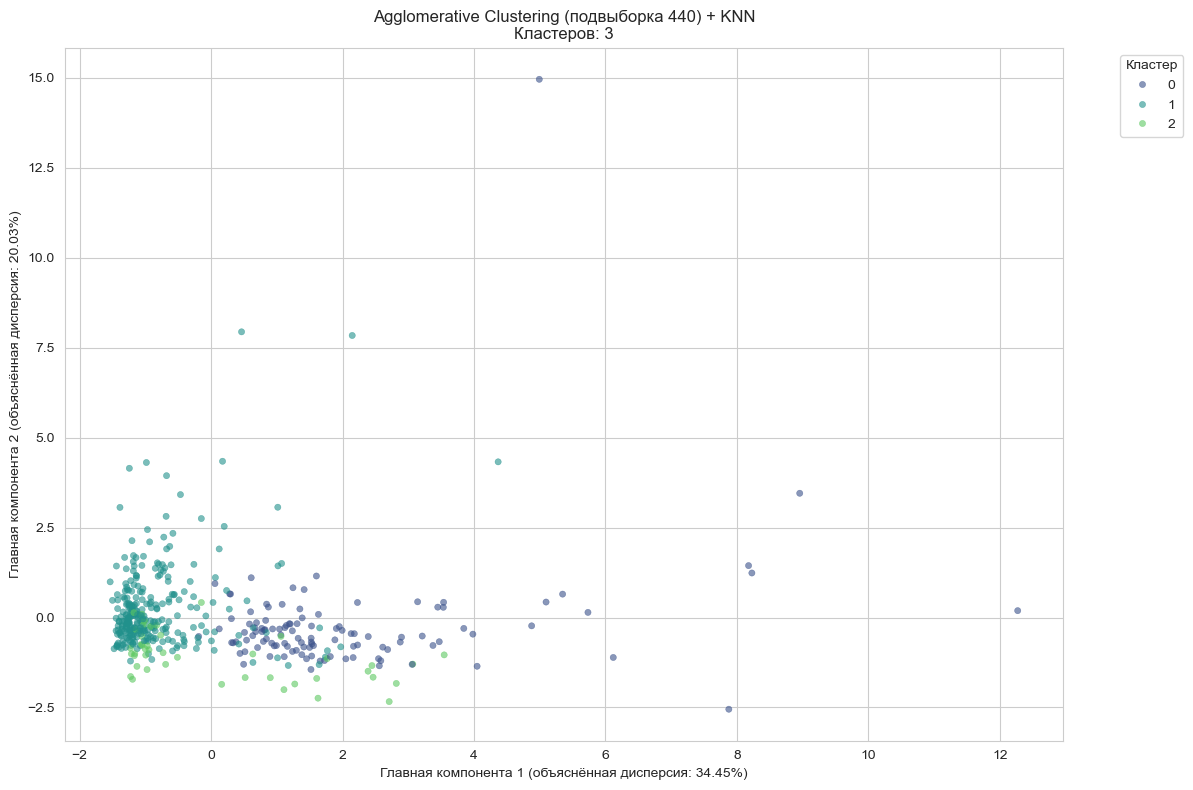

In [83]:
pca_df_agg = pd.DataFrame({
    'PCA1': X_pca_agg[:, 0],
    'PCA2': X_pca_agg[:, 1],
    'Cluster': labels_agg.astype(str)
})

palette_agg = {str(i): color for i, color in enumerate(sns.color_palette("viridis", n_clusters_found_agg))}

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=pca_df_agg,
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette=palette_agg,
    alpha=0.6,
    edgecolor=None,
    s=20
)
plt.title(f'Agglomerative Clustering (подвыборка {sample_size_agg}) + KNN\n'
          f'Кластеров: {n_clusters_found_agg}')
plt.xlabel(f'Главная компонента 1 (объяснённая дисперсия: {pca_agg.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Главная компонента 2 (объяснённая дисперсия: {pca_agg.explained_variance_ratio_[1]:.2%})')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Средние значения признаков по кластерам (Agglomerative):
                Fresh      Milk   Grocery   Frozen  Detergents_Paper  \
cluster_agg                                                            
0             9613.63  11377.43  17155.42  1870.50           7571.81   
1            13370.04   3713.93   4282.44  3585.64            986.90   
2             9409.76   4830.67   7830.00  2869.60           2976.38   

             Delicassen  
cluster_agg              
0               2097.09  
1               1369.82  
2               1059.60  

Медианные значения признаков по кластерам (Agglomerative):
              Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
cluster_agg                                                               
0            6353.0  8397.0  12477.0  1059.0            5618.0      1371.0
1            9294.0  2394.0   2842.0  1902.0             410.5       821.0
2            7588.0  2335.0   5332.0  1455.0             710.0       868.0


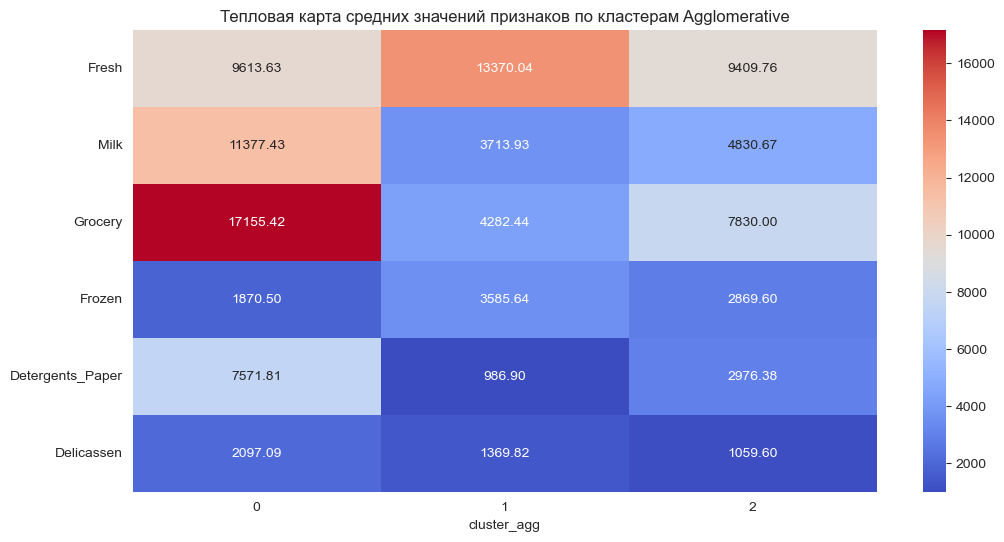

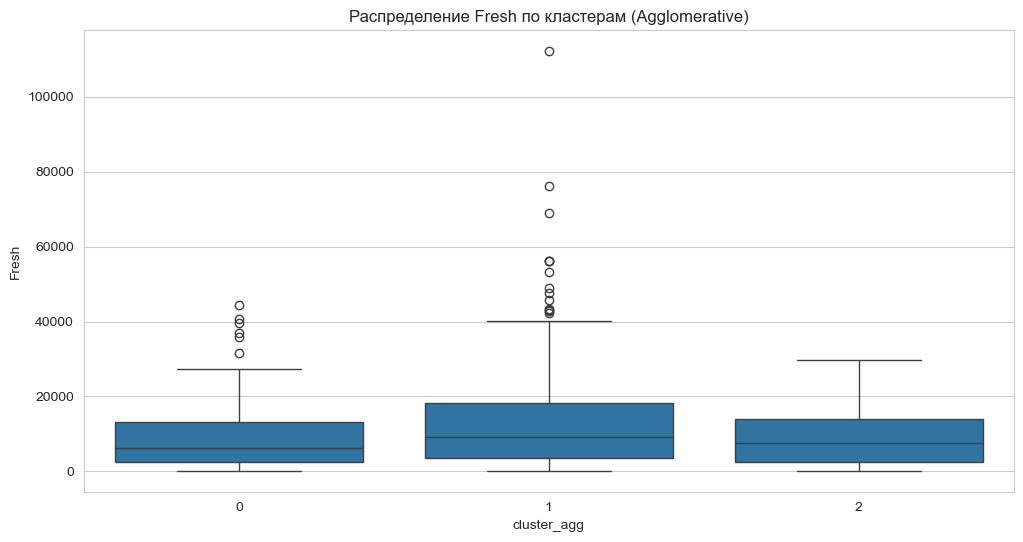

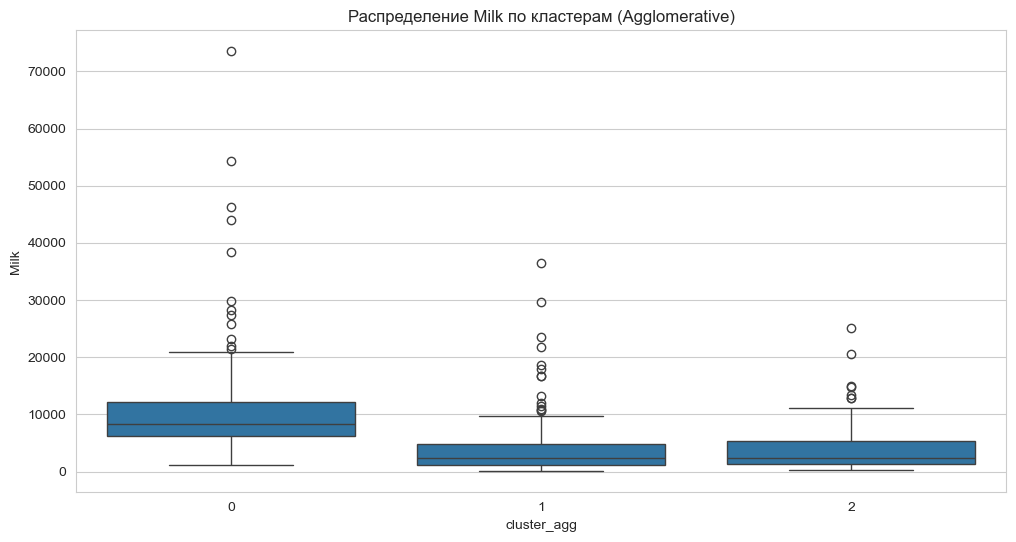

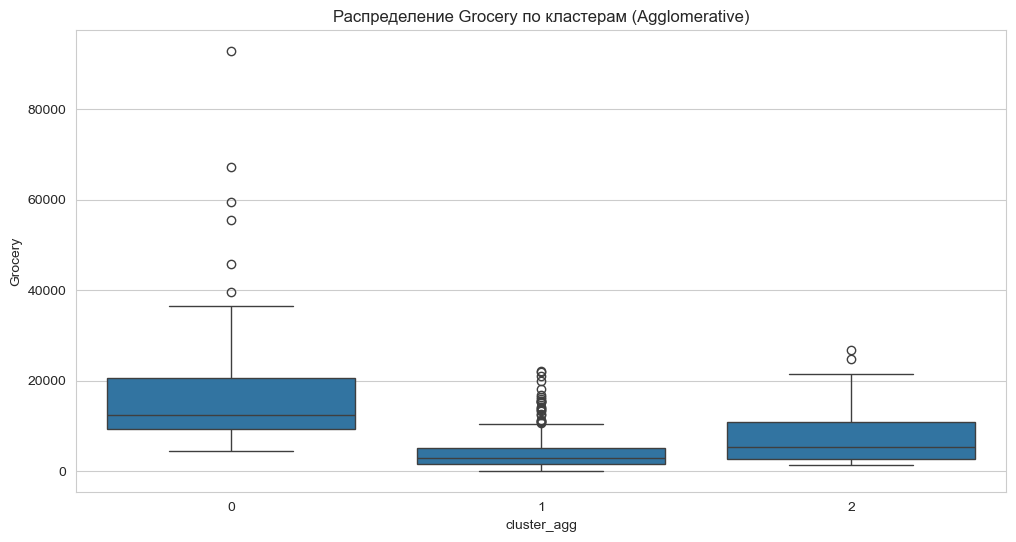

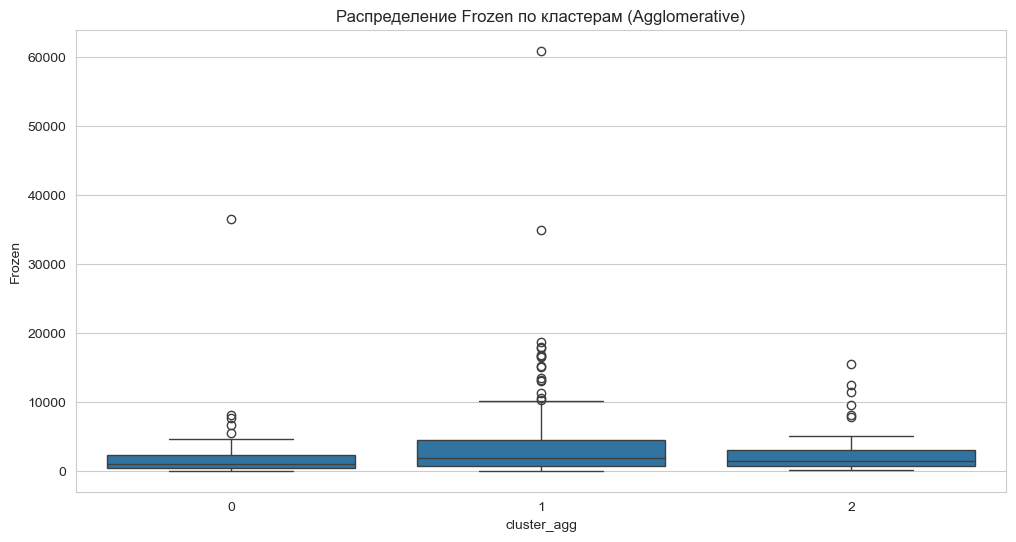

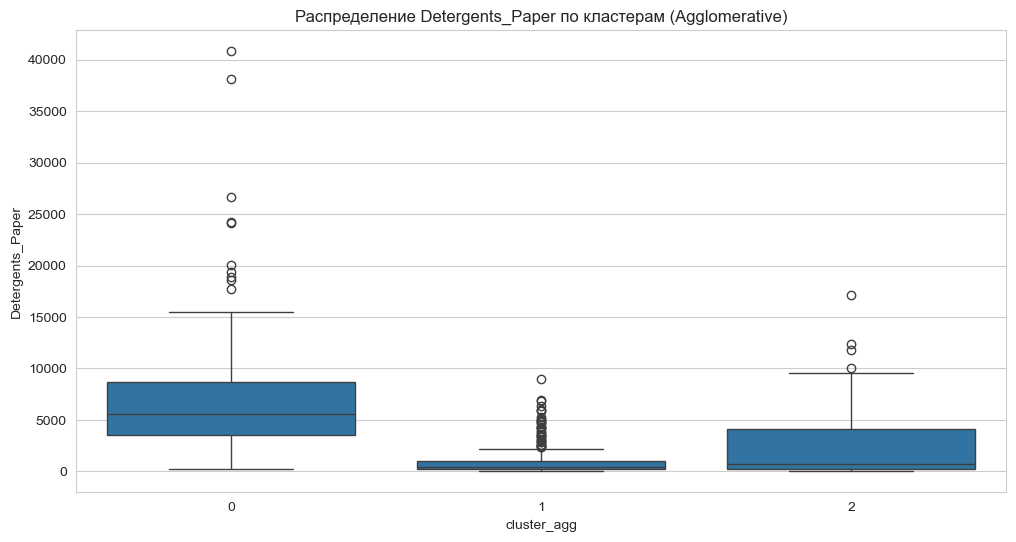

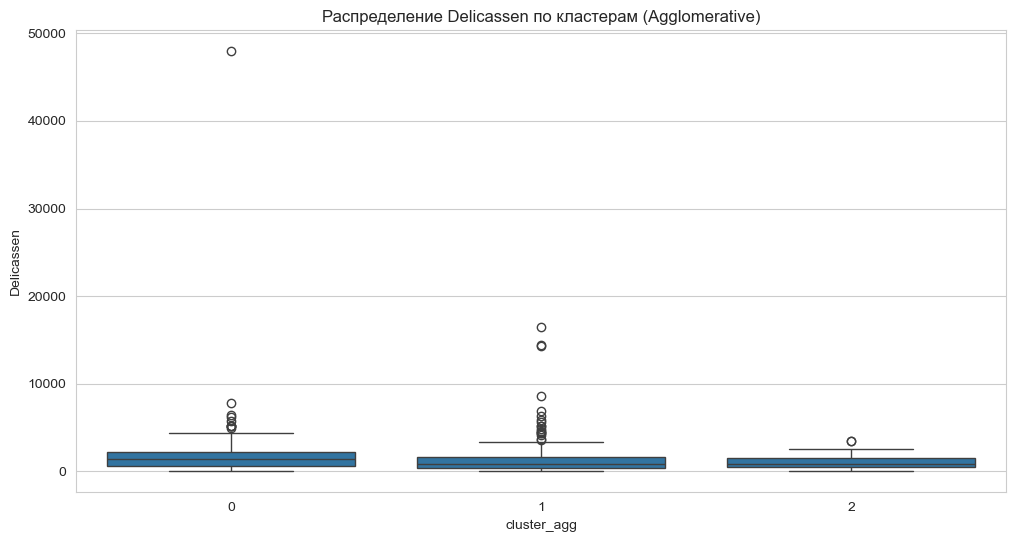


Средние значения one-hot признаков по кластерам (Agglomerative):
             Channel_2  Region_2  Region_3  cluster_kmeans  cluster_hdbscan
cluster_agg                                                                
0                 0.99      0.01      0.93            0.30             1.31
1                 0.04      0.00      0.75            1.46             2.13
2                 0.40      1.00      0.00            3.00            -0.11


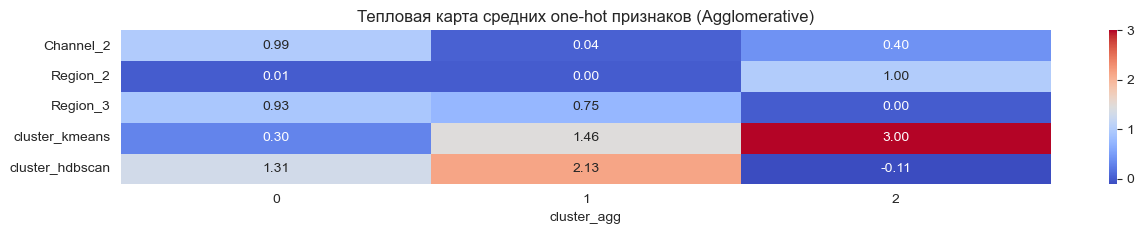

In [85]:
data['cluster_agg'] = labels_agg

df_no_noise_agg = data.copy()

cluster_profile_mean_agg = df_no_noise_agg.groupby('cluster_agg')[numeric_cols].mean()
cluster_profile_median_agg = df_no_noise_agg.groupby('cluster_agg')[numeric_cols].median()

print("\nСредние значения признаков по кластерам (Agglomerative):")
print(cluster_profile_mean_agg.round(2))

print("\nМедианные значения признаков по кластерам (Agglomerative):")
print(cluster_profile_median_agg.round(2))

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile_mean_agg.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта средних значений признаков по кластерам Agglomerative')
plt.show()

for col in numeric_cols:
    plt.figure()
    sns.boxplot(data=df_no_noise_agg, x='cluster_agg', y=col)
    plt.title(f'Распределение {col} по кластерам (Agglomerative)')
    plt.show()

cat_cols_agg = [col for col in data.columns if col not in numeric_cols + ['cluster_agg']]
cluster_cat_profile_agg = df_no_noise_agg.groupby('cluster_agg')[cat_cols_agg].mean()
print("\nСредние значения one-hot признаков по кластерам (Agglomerative):")
print(cluster_cat_profile_agg.round(2))

plt.figure(figsize=(15, 2))
sns.heatmap(cluster_cat_profile_agg.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта средних one-hot признаков (Agglomerative)')
plt.show()